In [14]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from google.oauth2 import service_account
from google.cloud import bigquery

PROJECT_ID       = "supply-chain-analytics-500607"
DATASET_ID       = "olist"
CREDENTIALS_PATH = "./bq_key.json"

credentials = service_account.Credentials.from_service_account_file(
    CREDENTIALS_PATH,
    scopes=["https://www.googleapis.com/auth/cloud-platform"]
)
client = bigquery.Client(project=PROJECT_ID, credentials=credentials)

os.makedirs("../data/charts", exist_ok=True)

def run_query(sql: str) -> pd.DataFrame:
    return client.query(sql).to_dataframe()

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "font.size":        11,
})

COLORS = {
    "Critical": "#d32f2f",
    "High":     "#f57c00",
    "Medium":   "#fbc02d",
    "Low":      "#388e3c",
    "blue":     "#1565C0",
    "grey":     "#90a4ae",
}

print("✅ Config loaded")

✅ Config loaded


In [15]:
TABLE      = f"`{PROJECT_ID}.{DATASET_ID}.orders_master`"
SELLER_SC  = f"`{PROJECT_ID}.{DATASET_ID}.seller_scorecard`"
ROUTE_RISK = f"`{PROJECT_ID}.{DATASET_ID}.route_risk`"
SLA        = f"`{PROJECT_ID}.{DATASET_ID}.sla_analysis`"
PRIORITY   = f"`{PROJECT_ID}.{DATASET_ID}.priority_orders`"
DEMAND     = f"`{PROJECT_ID}.{DATASET_ID}.demand_concentration`"

seller_scorecard     = run_query(f"SELECT * FROM {SELLER_SC}")
route_risk           = run_query(f"SELECT * FROM {ROUTE_RISK}")
sla_analysis         = run_query(f"SELECT * FROM {SLA}")
priority_orders      = run_query(f"SELECT * FROM {PRIORITY}")
demand_concentration = run_query(f"SELECT * FROM {DEMAND}")

print(f"seller_scorecard     : {seller_scorecard.shape}")
print(f"route_risk           : {route_risk.shape}")
print(f"sla_analysis         : {sla_analysis.shape}")
print(f"priority_orders      : {priority_orders.shape}")
print(f"demand_concentration : {demand_concentration.shape}")

/opt/anaconda3/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


seller_scorecard     : (1237, 10)
route_risk           : (100, 9)
sla_analysis         : (110189, 9)
priority_orders      : (110186, 12)
demand_concentration : (30, 7)


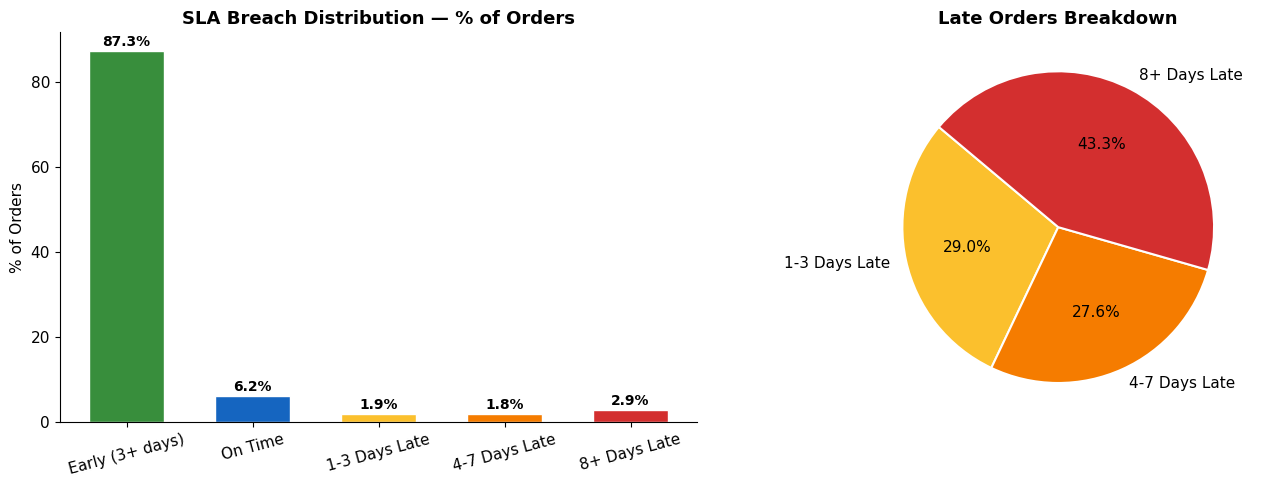

Saved → ../data/charts/01_sla_distribution.png


In [16]:
sla_order  = ["Early (3+ days)", "On Time", "1-3 Days Late", "4-7 Days Late", "8+ Days Late"]
sla_colors = ["#388e3c", "#1565C0", "#fbc02d", "#f57c00", "#d32f2f"]

sla_summary = (
    sla_analysis
    .groupby("sla_category")
    .agg(order_count=("order_id", "count"))
    .reset_index()
)
sla_summary["order_pct"] = (
    sla_summary["order_count"] / sla_summary["order_count"].sum() * 100
).round(2)
sla_summary["sla_category"] = pd.Categorical(
    sla_summary["sla_category"], categories=sla_order, ordered=True
)
sla_summary = sla_summary.sort_values("sla_category")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

bars = ax1.bar(
    sla_summary["sla_category"],
    sla_summary["order_pct"],
    color=sla_colors,
    edgecolor="white",
    width=0.6,
)
for bar, pct in zip(bars, sla_summary["order_pct"]):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{pct:.1f}%",
        ha="center", va="bottom", fontsize=10, fontweight="bold"
    )
ax1.set_title("SLA Breach Distribution — % of Orders", fontsize=13, fontweight="bold")
ax1.set_ylabel("% of Orders")
ax1.tick_params(axis="x", rotation=15)

late_mask = sla_summary["sla_category"].isin(["1-3 Days Late", "4-7 Days Late", "8+ Days Late"])
late_data = sla_summary[late_mask]
ax2.pie(
    late_data["order_count"],
    labels=late_data["sla_category"],
    colors=["#fbc02d", "#f57c00", "#d32f2f"],
    autopct="%1.1f%%",
    startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)
ax2.set_title("Late Orders Breakdown", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("../data/charts/01_sla_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → ../data/charts/01_sla_distribution.png")

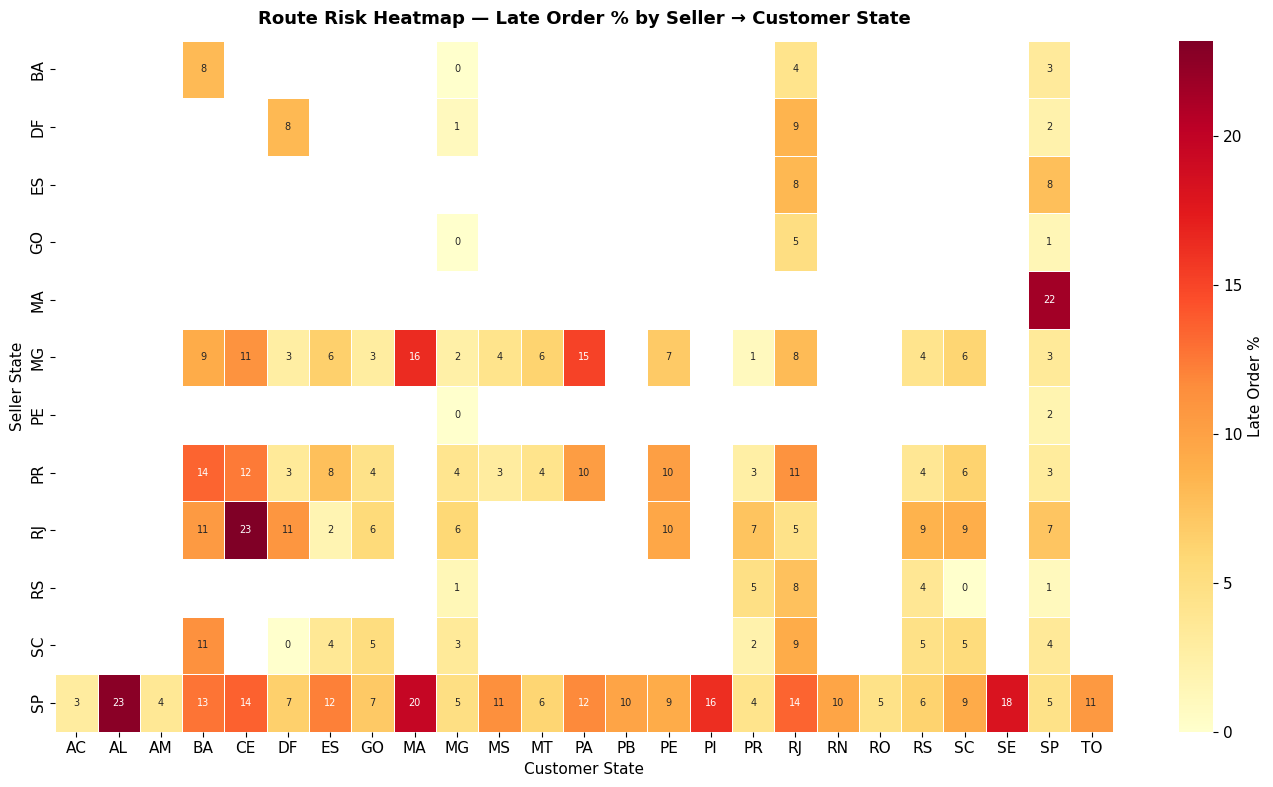

Saved → ../data/charts/02_route_risk_heatmap.png


In [28]:
pivot = route_risk.pivot_table(
    index="seller_state",
    columns="customer_state",
    values="late_pct",
    aggfunc="mean"
)

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    pivot,
    cmap="YlOrRd",
    linewidths=0.4,
    linecolor="white",
    annot=True,
    fmt=".0f",
    annot_kws={"size": 7},
    cbar_kws={"label": "Late Order %"},
    ax=ax,
)
ax.set_title("Route Risk Heatmap — Late Order % by Seller → Customer State",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Customer State", fontsize=11)
ax.set_ylabel("Seller State", fontsize=11)
plt.tight_layout()
plt.savefig("../data/charts/02_route_risk_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → ../data/charts/02_route_risk_heatmap.png")

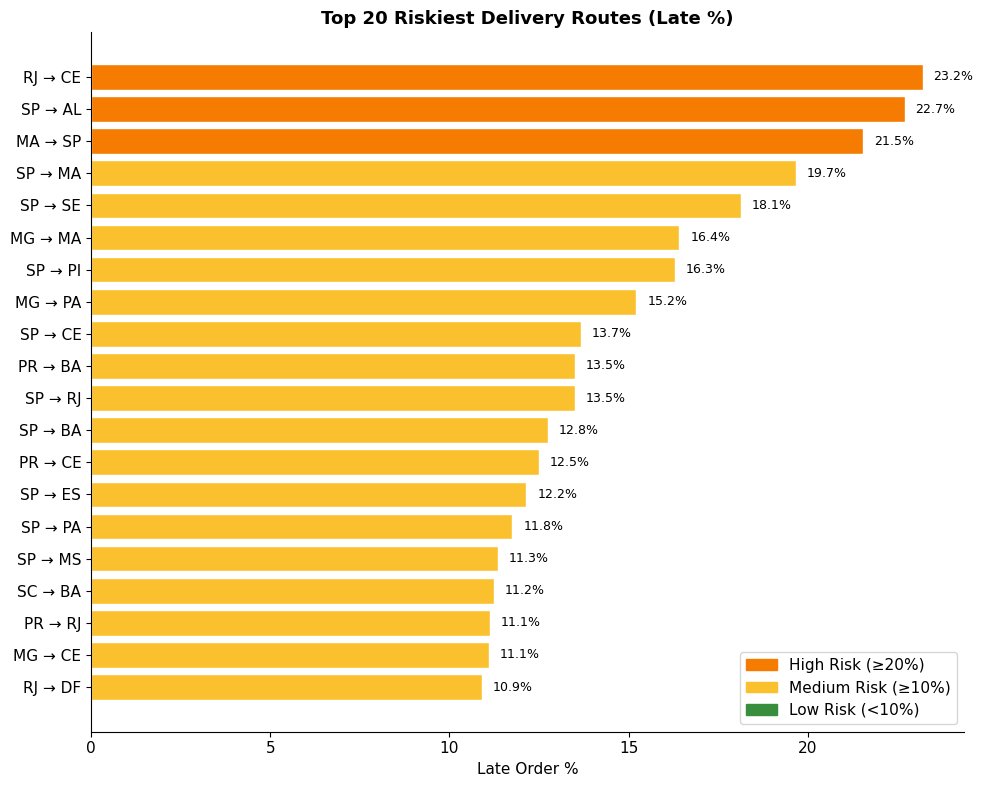

Saved → ../data/charts/03_top_routes.png


In [18]:
top_routes = route_risk.nlargest(20, "late_pct").copy()
top_routes["color"] = top_routes["risk_tier"].map(COLORS)

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(
    top_routes["route"],
    top_routes["late_pct"],
    color=top_routes["color"],
    edgecolor="white",
)
for bar, val in zip(bars, top_routes["late_pct"]):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}%",
        va="center", fontsize=9
    )
ax.set_title("Top 20 Riskiest Delivery Routes (Late %)", fontsize=13, fontweight="bold")
ax.set_xlabel("Late Order %")
ax.invert_yaxis()

legend_patches = [
    mpatches.Patch(color=COLORS["High"],   label="High Risk (≥20%)"),
    mpatches.Patch(color=COLORS["Medium"], label="Medium Risk (≥10%)"),
    mpatches.Patch(color=COLORS["Low"],    label="Low Risk (<10%)"),
]
ax.legend(handles=legend_patches, loc="lower right")
plt.tight_layout()
plt.savefig("../data/charts/03_top_routes.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → ../data/charts/03_top_routes.png")

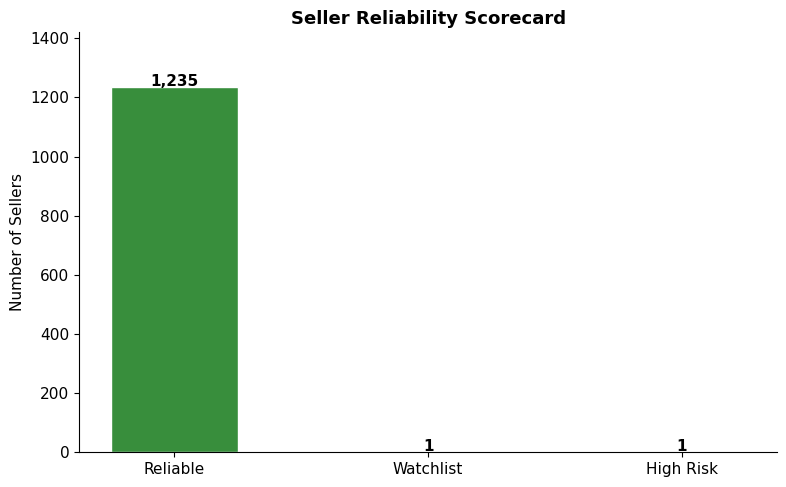

Saved → ../data/charts/04_seller_reliability.png


In [19]:
tier_counts = seller_scorecard["reliability_tier"].value_counts()
tier_order  = ["Reliable", "Watchlist", "High Risk"]
tier_colors = [COLORS["Low"], COLORS["Medium"], COLORS["Critical"]]
tier_counts = tier_counts.reindex(tier_order, fill_value=0)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    tier_counts.index,
    tier_counts.values,
    color=tier_colors,
    edgecolor="white",
    width=0.5,
)
for bar, val in zip(bars, tier_counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 5,
        f"{val:,}",
        ha="center", fontsize=11, fontweight="bold"
    )
ax.set_title("Seller Reliability Scorecard", fontsize=13, fontweight="bold")
ax.set_ylabel("Number of Sellers")
ax.set_ylim(0, tier_counts.max() * 1.15)
plt.tight_layout()
plt.savefig("../data/charts/04_seller_reliability.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → ../data/charts/04_seller_reliability.png")

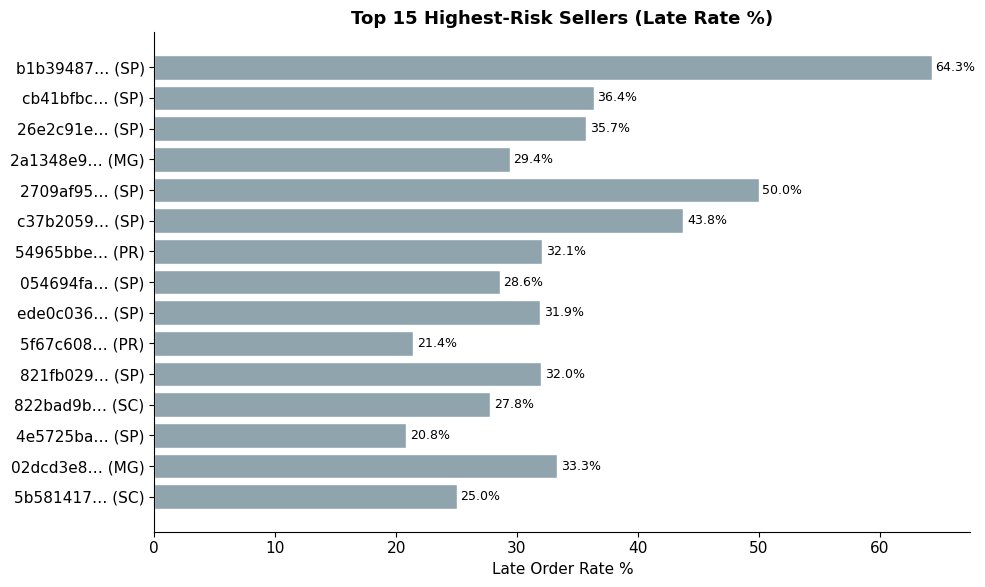

Saved → ../data/charts/05_high_risk_sellers.png


In [20]:
high_risk_sellers = (
    seller_scorecard
    .nsmallest(15, "reliability_score")[
        ["seller_id", "seller_state", "total_orders",
         "late_rate", "avg_delay_days", "reliability_score", "reliability_tier"]
    ]
    .copy()
)
high_risk_sellers["label"] = (
    high_risk_sellers["seller_id"].str[:8] + "…" +
    " (" + high_risk_sellers["seller_state"] + ")"
)

# Safe color mapping — fallback to grey if tier not in COLORS
high_risk_sellers["color"] = (
    high_risk_sellers["reliability_tier"]
    .map(COLORS)
    .fillna(COLORS["grey"])
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    high_risk_sellers["label"],
    high_risk_sellers["late_rate"],
    color=high_risk_sellers["color"].tolist(),
    edgecolor="white",
)
for bar, val in zip(bars, high_risk_sellers["late_rate"]):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.1f}%",
        va="center", fontsize=9
    )
ax.set_title("Top 15 Highest-Risk Sellers (Late Rate %)", fontsize=13, fontweight="bold")
ax.set_xlabel("Late Order Rate %")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../data/charts/05_high_risk_sellers.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → ../data/charts/05_high_risk_sellers.png")

/opt/anaconda3/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


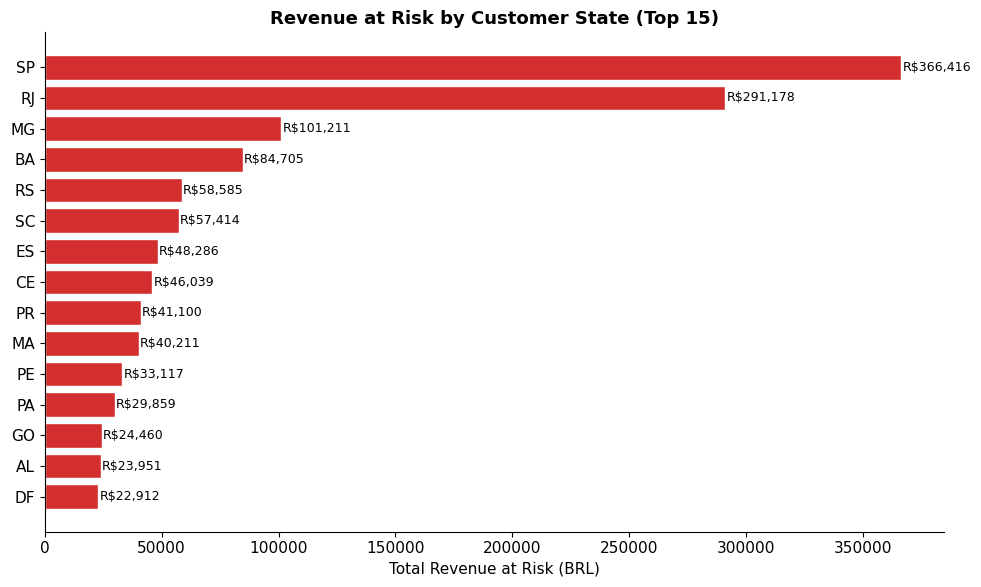

Saved → ../data/charts/06_revenue_at_risk_by_state.png


In [21]:
revenue_by_state = run_query(f"""
    SELECT
        customer_state,
        ROUND(SUM(revenue_at_risk), 2)      AS total_revenue_at_risk,
        COUNT(DISTINCT order_id)            AS late_orders,
        ROUND(AVG(delivery_delay_days), 2)  AS avg_delay_days
    FROM {TABLE}
    WHERE is_late = 1
      AND revenue_at_risk IS NOT NULL
    GROUP BY customer_state
    ORDER BY total_revenue_at_risk DESC
    LIMIT 15
""")

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(
    revenue_by_state["customer_state"],
    revenue_by_state["total_revenue_at_risk"],
    color=COLORS["Critical"],
    edgecolor="white",
)
for bar, val in zip(bars, revenue_by_state["total_revenue_at_risk"]):
    ax.text(
        bar.get_width() + 500,
        bar.get_y() + bar.get_height() / 2,
        f"R${val:,.0f}",
        va="center", fontsize=9
    )
ax.set_title("Revenue at Risk by Customer State (Top 15)", fontsize=13, fontweight="bold")
ax.set_xlabel("Total Revenue at Risk (BRL)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../data/charts/06_revenue_at_risk_by_state.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → ../data/charts/06_revenue_at_risk_by_state.png")

In [26]:
# Run this to see actual column names
sample = run_query(f"SELECT * FROM {TABLE} LIMIT 1")
print(sample.columns.tolist())

/opt/anaconda3/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'total_payment_value', 'payment_installments', 'payment_type', 'review_score', 'review_comment_message', 'delivery_delay_days', 'shipping_duration_days', 'is_late', 'order_month', 'order_year', 'order_month_num', 'order_dayofweek', 'revenue_at_risk', 'demand_concentration_score']


    order_month_num order_month  total_orders  late_pct  revenue_at_risk
0                 1     2018-01          7069      5.76         99463.74
1                 1     2017-01           750      2.63          3863.20
2                 2     2018-02          6555     13.91        186500.34
3                 2     2017-02          1653      3.12          8657.44
4                 3     2017-03          2546      4.69         24925.68
5                 3     2018-03          7003     18.05        267917.19
6                 4     2017-04          2303      6.23         34601.15
7                 4     2018-04          6798      4.08         60687.14
8                 5     2017-05          3545      3.20         22743.65
9                 5     2018-05          6749      6.34         90832.09
10                6     2017-06          3135      2.95         29691.80
11                6     2018-06          6096      1.16         19590.87
12                7     2017-07          3872      

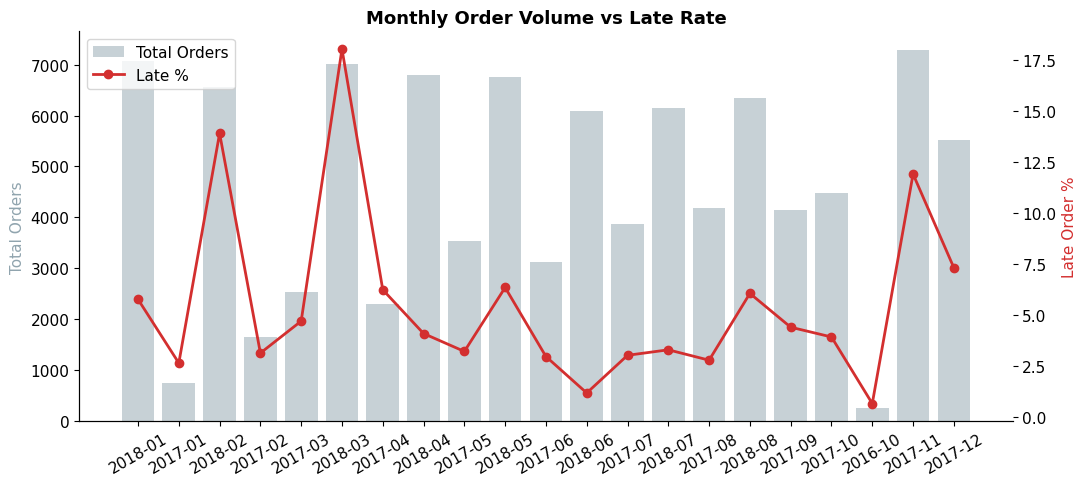

Saved → ../data/charts/07_monthly_trend.png


In [27]:
monthly = run_query(f"""
    SELECT
        order_month_num,
        order_month,
        COUNT(DISTINCT order_id)                AS total_orders,
        ROUND(SUM(is_late) / COUNT(*) * 100, 2) AS late_pct,
        ROUND(SUM(revenue_at_risk), 2)          AS revenue_at_risk
    FROM {TABLE}
    WHERE order_month_num IS NOT NULL
      AND delivery_delay_days IS NOT NULL
    GROUP BY order_month_num, order_month
    HAVING total_orders >= 50
    ORDER BY order_month_num ASC
""")

print(monthly)

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

ax1.bar(
    monthly["order_month"],
    monthly["total_orders"],
    color=COLORS["grey"],
    alpha=0.5,
    label="Total Orders",
)
ax2.plot(
    monthly["order_month"],
    monthly["late_pct"],
    color=COLORS["Critical"],
    marker="o",
    linewidth=2,
    label="Late %",
)

ax1.set_ylabel("Total Orders", color=COLORS["grey"])
ax2.set_ylabel("Late Order %", color=COLORS["Critical"])
ax1.set_title("Monthly Order Volume vs Late Rate", fontsize=13, fontweight="bold")
ax1.tick_params(axis="x", rotation=30)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
plt.tight_layout()
plt.savefig("../data/charts/07_monthly_trend.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → ../data/charts/07_monthly_trend.png")

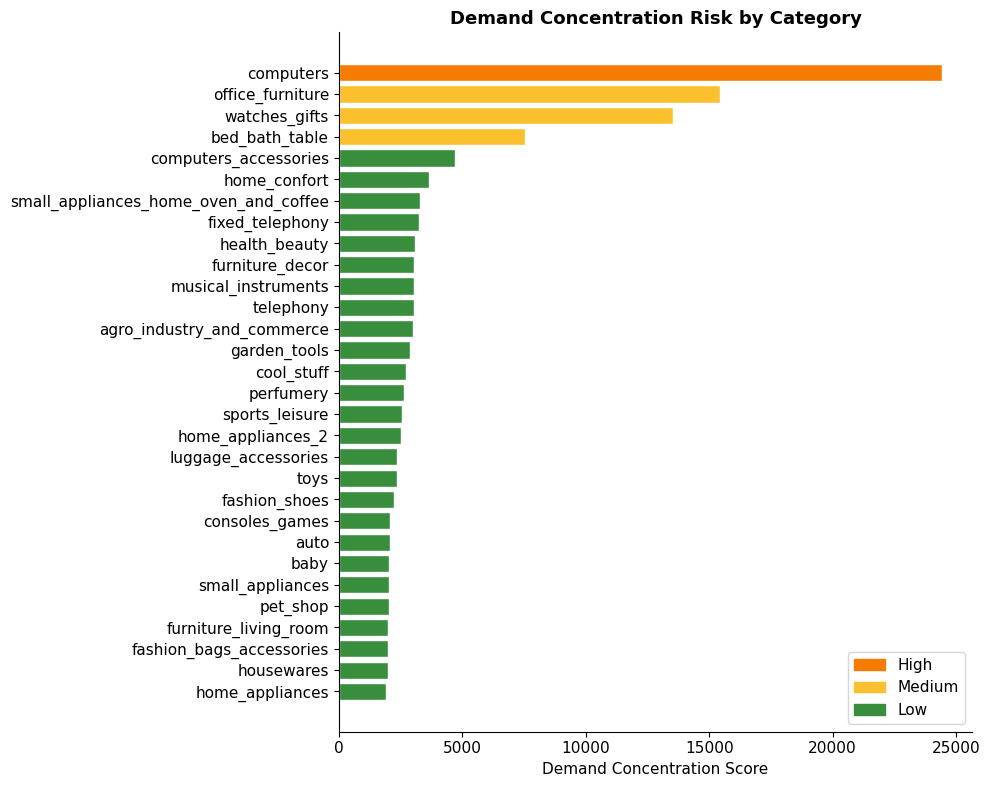

Saved → ../data/charts/08_demand_concentration.png


In [23]:
demand_concentration["color"] = demand_concentration["risk_label"].map(COLORS)
dc_sorted = demand_concentration.sort_values("demand_concentration_score", ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(
    dc_sorted["category"],
    dc_sorted["demand_concentration_score"],
    color=dc_sorted["color"],
    edgecolor="white",
)
ax.set_title("Demand Concentration Risk by Category", fontsize=13, fontweight="bold")
ax.set_xlabel("Demand Concentration Score")

legend_patches = [
    mpatches.Patch(color=COLORS["High"],   label="High"),
    mpatches.Patch(color=COLORS["Medium"], label="Medium"),
    mpatches.Patch(color=COLORS["Low"],    label="Low"),
]
ax.legend(handles=legend_patches, loc="lower right")
plt.tight_layout()
plt.savefig("../data/charts/08_demand_concentration.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → ../data/charts/08_demand_concentration.png")

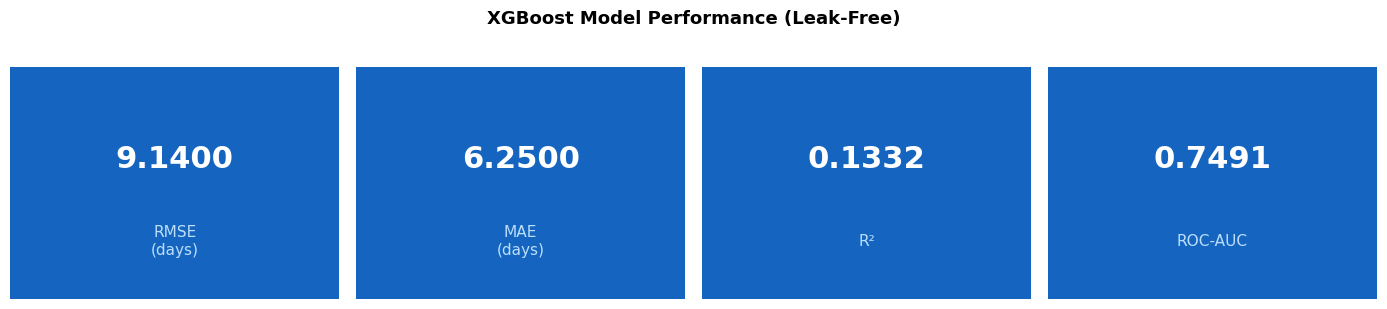

Saved → ../data/charts/09_model_performance.png


In [24]:
metrics = {
    "RMSE\n(days)": 9.14,
    "MAE\n(days)":  6.25,
    "R²":           0.1332,
    "ROC-AUC":      0.7491,
}

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
for ax, (label, val) in zip(axes, metrics.items()):
    ax.set_facecolor("#1565C0")
    ax.text(0.5, 0.6, f"{val:.4f}", ha="center", va="center",
            fontsize=22, fontweight="bold", color="white",
            transform=ax.transAxes)
    ax.text(0.5, 0.25, label, ha="center", va="center",
            fontsize=11, color="#bbdefb",
            transform=ax.transAxes)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

fig.suptitle("XGBoost Model Performance (Leak-Free)", fontsize=13,
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../data/charts/09_model_performance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → ../data/charts/09_model_performance.png")

In [25]:
import glob

charts = sorted(glob.glob("../data/charts/*.png"))

print("=" * 60)
print("04_risk_intelligence.ipynb — COMPLETE")
print("=" * 60)
print(f"\n📊 Charts saved ({len(charts)} files):")
for c in charts:
    print(f"   {os.path.basename(c)}")

print(f"""
📌 Key Findings:
   • {sla_analysis[sla_analysis['sla_category'].isin(['1-3 Days Late','4-7 Days Late','8+ Days Late'])].shape[0]:,} late orders across 3 severity tiers
   • {route_risk[route_risk['risk_tier'].isin(['High','Critical'])].shape[0]} high/critical risk routes identified
   • {seller_scorecard[seller_scorecard['reliability_tier'] == 'High Risk'].shape[0]} high-risk sellers flagged
   • ROC-AUC 0.7491 — model correctly ranks late order risk

Next → README.md + GitHub push
""")

04_risk_intelligence.ipynb — COMPLETE

📊 Charts saved (9 files):
   01_sla_distribution.png
   02_route_risk_heatmap.png
   03_top_routes.png
   04_seller_reliability.png
   05_high_risk_sellers.png
   06_revenue_at_risk_by_state.png
   07_monthly_trend.png
   08_demand_concentration.png
   09_model_performance.png

📌 Key Findings:
   • 7,264 late orders across 3 severity tiers
   • 3 high/critical risk routes identified
   • 1 high-risk sellers flagged
   • ROC-AUC 0.7491 — model correctly ranks late order risk

Next → README.md + GitHub push

